# 05 — Sentiment Analysis (Corrected)

This notebook performs sentiment analysis on the cleaned news dataset.

### Important correction
VADER is calculated from the **original cleaned text**, not the aggressively processed/lemmatized TF-IDF text. This preserves punctuation and wording that can be useful to VADER.

The dataset-provided `sentiment` label remains the primary label. VADER is used only as an independent comparison.

**No news dates are created because the supplied news dataset has no date column.**


In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.stats import spearmanr

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)


## 1. Project paths

In [2]:
PROJECT_ROOT = Path.cwd().resolve()

# If this notebook is executed from the notebooks/ directory
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

CLEAN_NEWS = INTERIM_DIR / "cleaned_news.csv"
NLP_FEATURES = PROCESSED_DIR / "news_nlp_features.csv"
PROCESSED_NEWS = PROCESSED_DIR / "processed_news.csv"

print("Project root:", PROJECT_ROOT)
print("Clean news:", CLEAN_NEWS.exists())
print("NLP features:", NLP_FEATURES.exists())
print("Processed news:", PROCESSED_NEWS.exists())


Project root: C:\Users\ankit\Desktop\Ml-Project\AI-Supply-Chain-Digital-Marketing-v1
Clean news: True
NLP features: True
Processed news: True


## 2. Load cleaned news data

In [3]:
news = pd.read_csv(CLEAN_NEWS, encoding="latin1")

required_columns = {"sentiment", "text"}
missing_columns = required_columns - set(news.columns)

assert not missing_columns, f"Missing required columns: {missing_columns}"

news["sentiment"] = news["sentiment"].astype(str).str.strip().str.lower()
news["text"] = news["text"].fillna("").astype(str)

print("News shape:", news.shape)
print("Columns:", news.columns.tolist())
display(news.head())


News shape: (4840, 2)
Columns: ['sentiment', 'text']


,sentiment,text
0,neutral,"According to Gran , the company has no plans to move all production to Russia , although that is where the company i..."
1,neutral,"Technopolis plans to develop in stages an area of no less than 100,000 square meters in order to host companies work..."
2,negative,The international electronic industry company Elcoteq has laid off tens of employees from its Tallinn facility ; con...
3,positive,With the new production plant the company would increase its capacity to meet the expected increase in demand and wo...
4,positive,"According to the company 's updated strategy for the years 2009-2012 , Basware targets a long-term net sales growth ..."


## 3. Validate supplied sentiment labels

In [4]:
allowed_labels = {"negative", "neutral", "positive"}

unexpected_labels = sorted(
    set(news["sentiment"]) - allowed_labels
)

print("Unexpected labels:", unexpected_labels)

sentiment_counts = (
    news["sentiment"]
    .value_counts()
    .reindex(["negative", "neutral", "positive"])
    .fillna(0)
    .astype(int)
)

display(sentiment_counts.rename("count").to_frame())

assert not unexpected_labels
assert news["text"].str.strip().ne("").all()


Unexpected labels: []


,count
sentiment,
negative,604
neutral,2873
positive,1363


## 4. Map supplied labels to numeric scores

This is the same representation used in Notebook 04:

- negative = -1
- neutral = 0
- positive = 1


In [5]:
label_to_score = {
    "negative": -1,
    "neutral": 0,
    "positive": 1
}

news["label_score"] = news["sentiment"].map(label_to_score).astype(int)

assert news["label_score"].notna().all()

display(
    news[["sentiment", "label_score"]]
    .drop_duplicates()
    .sort_values("label_score")
)


,sentiment,label_score
2,negative,-1
0,neutral,0
3,positive,1


## 5. Prepare text for VADER

### This is the main code change

Use the **cleaned original text** for VADER.

Do **not** use:
- stopword-removed text
- lemmatized text
- TF-IDF vectors

VADER is a lexicon/rule-based sentiment analyzer and can use textual cues such as punctuation and emphasis.


In [6]:
def prepare_vader_text(text):
    # Keep the wording and punctuation from the cleaned news text.
    # Only normalize repeated whitespace.
    text = str(text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

news["vader_text"] = news["text"].map(prepare_vader_text)

display(
    news[["text", "vader_text"]].head(10)
)


,text,vader_text
0,"According to Gran , the company has no plans to move all production to Russia , although that is where the company i...","According to Gran , the company has no plans to move all production to Russia , although that is where the company i..."
1,"Technopolis plans to develop in stages an area of no less than 100,000 square meters in order to host companies work...","Technopolis plans to develop in stages an area of no less than 100,000 square meters in order to host companies work..."
2,The international electronic industry company Elcoteq has laid off tens of employees from its Tallinn facility ; con...,The international electronic industry company Elcoteq has laid off tens of employees from its Tallinn facility ; con...
3,With the new production plant the company would increase its capacity to meet the expected increase in demand and wo...,With the new production plant the company would increase its capacity to meet the expected increase in demand and wo...
4,"According to the company 's updated strategy for the years 2009-2012 , Basware targets a long-term net sales growth ...","According to the company 's updated strategy for the years 2009-2012 , Basware targets a long-term net sales growth ..."
5,FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is aggressively pursuing its growth strategy by increasingly focusing on te...,FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is aggressively pursuing its growth strategy by increasingly focusing on te...
6,"For the last quarter of 2010 , Componenta 's net sales doubled to EUR131m from EUR76m for the same period a year ear...","For the last quarter of 2010 , Componenta 's net sales doubled to EUR131m from EUR76m for the same period a year ear..."
7,"In the third quarter of 2010 , net sales increased by 5.2 % to EUR 205.5 mn , and operating profit by 34.9 % to EUR ...","In the third quarter of 2010 , net sales increased by 5.2 % to EUR 205.5 mn , and operating profit by 34.9 % to EUR ..."
8,Operating profit rose to EUR 13.1 mn from EUR 8.7 mn in the corresponding period in 2007 representing 7.7 % of net s...,Operating profit rose to EUR 13.1 mn from EUR 8.7 mn in the corresponding period in 2007 representing 7.7 % of net s...
9,"Operating profit totalled EUR 21.1 mn , up from EUR 18.6 mn in 2007 , representing 9.7 % of net sales .","Operating profit totalled EUR 21.1 mn , up from EUR 18.6 mn in 2007 , representing 9.7 % of net sales ."


## 6. Load VADER

In [7]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

try:
    nltk.data.find("sentiment/vader_lexicon.zip")
except LookupError:
    nltk.download("vader_lexicon", quiet=True)

sia = SentimentIntensityAnalyzer()

print("VADER loaded successfully.")


VADER loaded successfully.


## 7. Calculate VADER scores

In [8]:
vader_scores = (
    news["vader_text"]
    .map(sia.polarity_scores)
    .apply(pd.Series)
    .rename(
        columns={
            "neg": "vader_neg",
            "neu": "vader_neu",
            "pos": "vader_pos",
            "compound": "vader_compound"
        }
    )
)

news = pd.concat([news, vader_scores], axis=1)

display(
    news[
        [
            "sentiment",
            "vader_neg",
            "vader_neu",
            "vader_pos",
            "vader_compound"
        ]
    ].head(10)
)

display(news["vader_compound"].describe())


,sentiment,vader_neg,vader_neu,vader_pos,vader_compound
0,neutral,0.092,0.837,0.071,-0.1280
1,neutral,0.073,0.927,0.000,-0.2960
2,negative,0.000,1.000,0.000,0.0000
3,positive,0.038,0.660,0.302,0.8555
4,positive,0.000,0.853,0.147,0.6705
5,positive,0.148,0.657,0.195,0.3485
6,positive,0.064,0.856,0.080,0.1531
7,positive,0.000,0.815,0.185,0.6124
8,positive,0.000,0.879,0.121,0.4404
9,positive,0.000,0.854,0.146,0.4404


count    4840.000000
mean        0.184559
std         0.301215
min        -0.865800
25%         0.000000
50%         0.000000
75%         0.440400
max         0.946000
Name: vader_compound, dtype: float64

## 8. Convert VADER compound score into three classes

Standard VADER thresholds:

- compound <= -0.05 → negative
- -0.05 < compound < 0.05 → neutral
- compound >= 0.05 → positive


In [9]:
def vader_class(compound):
    if compound <= -0.05:
        return "negative"
    elif compound >= 0.05:
        return "positive"
    else:
        return "neutral"

news["vader_sentiment"] = news["vader_compound"].map(vader_class)

vader_counts = (
    news["vader_sentiment"]
    .value_counts()
    .reindex(["negative", "neutral", "positive"])
    .fillna(0)
    .astype(int)
)

display(vader_counts.rename("count").to_frame())


,count
vader_sentiment,
negative,445
neutral,2002
positive,2393


## 9. Compare supplied sentiment with VADER

This comparison is descriptive. It does not mean VADER is the ground truth, and it does not establish causality with supply-chain disruptions.


In [10]:
news["vader_matches_label"] = (
    news["sentiment"] == news["vader_sentiment"]
)

agreement_rate = news["vader_matches_label"].mean()

print(f"VADER agreement with supplied labels: {agreement_rate:.4f}")

comparison = pd.crosstab(
    news["sentiment"],
    news["vader_sentiment"],
    rownames=["supplied_sentiment"],
    colnames=["vader_sentiment"],
    dropna=False
)

display(comparison)


VADER agreement with supplied labels: 0.5434


vader_sentiment,negative,neutral,positive
supplied_sentiment,,,
negative,180,185,239
neutral,197,1486,1190
positive,68,331,964


## 10. Correlation between supplied label score and VADER compound score

In [11]:
spearman_corr, spearman_p = spearmanr(
    news["label_score"],
    news["vader_compound"]
)

print(f"Spearman correlation: {spearman_corr:.4f}")
print(f"p-value: {spearman_p:.6g}")

print("\nVADER compound score by supplied sentiment:")

display(
    news.groupby("sentiment")["vader_compound"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .reindex(["negative", "neutral", "positive"])
)


Spearman correlation: 0.3095
p-value: 6.14345e-108

VADER compound score by supplied sentiment:


,count,mean,median,std,min,max
sentiment,,,,,,
negative,604,0.028814,0.0000,0.331035,-0.8572,0.8319
neutral,2873,0.150524,0.0000,0.266620,-0.8658,0.9337
positive,1363,0.325317,0.3818,0.301515,-0.6166,0.9460


## 11. Sentiment distribution

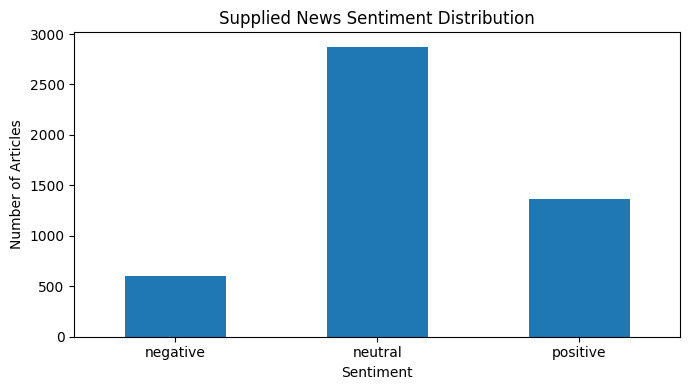

In [12]:
label_counts = (
    news["sentiment"]
    .value_counts()
    .reindex(["negative", "neutral", "positive"])
)

plt.figure(figsize=(7, 4))
label_counts.plot(kind="bar")
plt.title("Supplied News Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Articles")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 12. VADER compound distribution

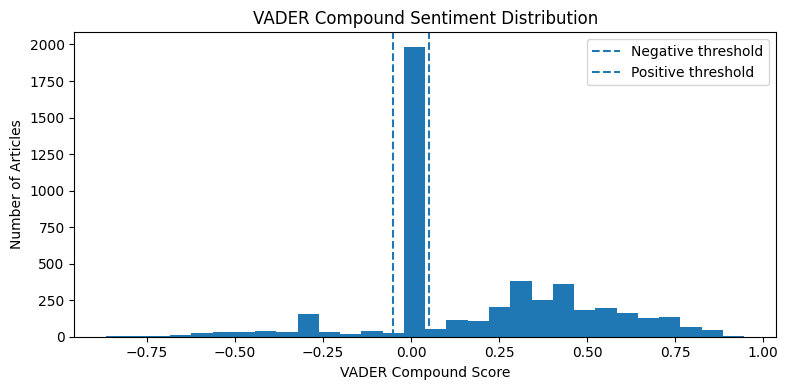

In [13]:
plt.figure(figsize=(8, 4))
plt.hist(news["vader_compound"], bins=30)
plt.axvline(-0.05, linestyle="--", label="Negative threshold")
plt.axvline(0.05, linestyle="--", label="Positive threshold")
plt.title("VADER Compound Sentiment Distribution")
plt.xlabel("VADER Compound Score")
plt.ylabel("Number of Articles")
plt.legend()
plt.tight_layout()
plt.show()


## 13. Inspect disagreements

This helps identify why a general-purpose VADER lexicon may disagree with the supplied news sentiment labels.


In [14]:
disagreements = news.loc[
    ~news["vader_matches_label"],
    [
        "sentiment",
        "vader_sentiment",
        "vader_compound",
        "text"
    ]
].copy()

print("Number of disagreements:", len(disagreements))
display(disagreements.head(20))


Number of disagreements: 2210


,sentiment,vader_sentiment,vader_compound,text
0,neutral,negative,-0.1280,"According to Gran , the company has no plans to move all production to Russia , although that is where the company i..."
1,neutral,negative,-0.2960,"Technopolis plans to develop in stages an area of no less than 100,000 square meters in order to host companies work..."
2,negative,neutral,0.0000,The international electronic industry company Elcoteq has laid off tens of employees from its Tallinn facility ; con...
18,positive,neutral,0.0000,"Incap Contract Manufacturing Services Pvt Ltd , a subsidiary of Incap Corporation of Finland , plans to double its r..."
20,positive,neutral,0.0000,"Lifetree was founded in 2000 , and its revenues have risen on an average by 40 % with margins in late 30s ."
23,positive,neutral,0.0000,"Net income from life insurance doubled to EUR 6.8 mn from EUR 3.2 mn , and net income from non-life insurance rose t..."
25,positive,neutral,0.0000,"Net sales surged by 18.5 % to EUR167 .8 m. Teleste said that EUR20 .4 m , or 12.2 % , of the sales came from the acq..."
32,positive,neutral,0.0000,"The Lithuanian beer market made up 14.41 million liters in January , a rise of 0.8 percent from the year-earlier fig..."
37,positive,neutral,0.0000,"Aspo Plc STOCK EXCHANGE RELEASE February 11 , 2011 at8 .45 a.m. ESL Shipping Ltd , part of Aspo Group , has signed a..."
39,positive,neutral,0.0000,"In January , traffic , measured in revenue passenger kilometres RPK , went up by 3.2 % and capacity , measured in av..."


## 14. Sentiment versus text length

In [15]:
news["text_length"] = news["text"].str.len()
news["word_count"] = news["text"].str.split().str.len()

display(
    news.groupby("sentiment")[["text_length", "word_count"]]
    .agg(["count", "mean", "median"])
    .reindex(["negative", "neutral", "positive"])
)


text_length                    word_count                  
                count        mean median      count       mean median
sentiment                                                            
negative          604  125.753311  117.5        604  23.917219   22.0
neutral          2873  124.993735  116.0       2873  22.160808   21.0
positive         1363  135.658107  128.0       1363  24.692590   23.0

## 15. Verify consistency with Notebook 04

Notebook 04 created `news_nlp_features.csv` with the `sentiment_score` column.

This check verifies that the supplied sentiment mapping is consistent with that file.


In [16]:
if NLP_FEATURES.exists():
    nlp_features = pd.read_csv(NLP_FEATURES, encoding="utf-8")

    print("NLP feature shape:", nlp_features.shape)

    assert "sentiment_score" in nlp_features.columns

    if len(nlp_features) == len(news):
        scores_match = np.array_equal(
            news["label_score"].to_numpy(),
            nlp_features["sentiment_score"].to_numpy()
        )
        print("Notebook 04 sentiment scores match:", scores_match)
        assert scores_match
    else:
        print(
            "Row count differs, so sequence-level comparison was skipped."
        )
else:
    print("Notebook 04 NLP feature file was not found.")


NLP feature shape: (4840, 1012)
Notebook 04 sentiment scores match: True


## 16. Save sentiment-analysis features

This file is an analysis/feature artifact. It is **not** a pre-filled model results or report matrix.


In [17]:
output_columns = [
    "sentiment",
    "label_score",
    "vader_neg",
    "vader_neu",
    "vader_pos",
    "vader_compound",
    "vader_sentiment",
    "vader_matches_label",
    "text_length",
    "word_count",
    "text"
]

sentiment_analysis = news[output_columns].copy()

output_path = PROCESSED_DIR / "sentiment_analysis.csv"

sentiment_analysis.to_csv(
    output_path,
    index=False,
    encoding="utf-8"
)

print("Saved:", output_path)
print("Shape:", sentiment_analysis.shape)


Saved: C:\Users\ankit\Desktop\Ml-Project\AI-Supply-Chain-Digital-Marketing-v1\data\processed\sentiment_analysis.csv
Shape: (4840, 11)


## 17. Final validation

In [18]:
validation = {
    "rows": len(sentiment_analysis),
    "rows_preserved": len(sentiment_analysis) == len(news),
    "missing_sentiment": int(sentiment_analysis["sentiment"].isna().sum()),
    "missing_label_score": int(sentiment_analysis["label_score"].isna().sum()),
    "missing_vader_compound": int(
        sentiment_analysis["vader_compound"].isna().sum()
    ),
    "missing_vader_sentiment": int(
        sentiment_analysis["vader_sentiment"].isna().sum()
    ),
    "infinite_vader_values": int(
        np.isinf(sentiment_analysis["vader_compound"]).sum()
    ),
    "output_exists": output_path.exists()
}

display(pd.DataFrame([validation]))

assert validation["rows_preserved"]
assert validation["missing_sentiment"] == 0
assert validation["missing_label_score"] == 0
assert validation["missing_vader_compound"] == 0
assert validation["missing_vader_sentiment"] == 0
assert validation["infinite_vader_values"] == 0
assert validation["output_exists"]

print("05_sentiment_analysis completed successfully.")


,rows,rows_preserved,missing_sentiment,missing_label_score,missing_vader_compound,missing_vader_sentiment,infinite_vader_values,output_exists
0,4840,True,0,0,0,0,0,True


05_sentiment_analysis completed successfully.


# Final interpretation

Use the following interpretation after running the notebook:

1. The dataset-provided sentiment labels remain the primary sentiment labels.
2. VADER is an independent lexicon-based comparison.
3. VADER agreement/correlation should be reported as a comparison result, not as proof that VADER is highly accurate.
4. VADER should not replace the supplied labels.
5. No news dates are fabricated, so this notebook does not claim that sentiment precedes shipment disruptions.
6. The resulting sentiment features can be used later in the feature-engineering/modeling pipeline.
